# AS Severity Classification with FT-Transformer

**Dataset:** EchoNext (PhysioNet) — ECG + Echocardiography derived features  
**Task:** 4-class classification of Aortic Stenosis severity: `normal`, `mild`, `moderate`, `severe`


## 1. Exploratory Data Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
})

# Severity class color palette
CLASS_ORDER = ['normal', 'mild', 'moderate', 'severe']
CLASS_COLORS = {
    'normal':   '#4CAF50',  # green
    'mild':     '#FFC107',  # amber
    'moderate': '#FF9800',  # orange
    'severe':   '#F44336',  # red
}

### 1.1 Load & Filter Dataset


In [2]:
df_raw = pd.read_csv('echonext_metadata_100k.csv', index_col=0)
print(f'Raw dataset shape: {df_raw.shape}')
print('\naortic_stenosis_value raw counts:')
display(df_raw['aortic_stenosis_value'].value_counts(dropna=False).to_frame('count'))

Raw dataset shape: (100000, 38)

aortic_stenosis_value raw counts:


,count
aortic_stenosis_value,
none,77518
NaN,9003
presumed none,6561
mild,2864
severe,2197
moderate,1857


In [3]:
# Keep only the 4 target classes; rename 'none' -> 'normal'
# Drop rows with 'presumed none' (ambiguous) and NaN
VALID_CLASSES = {'none', 'mild', 'moderate', 'severe'}

df = df_raw[df_raw['aortic_stenosis_value'].isin(VALID_CLASSES)].copy()
df['severity'] = df['aortic_stenosis_value'].replace({'none': 'normal'})
df['severity'] = pd.Categorical(df['severity'], categories=CLASS_ORDER, ordered=True)

print(f'Filtered dataset shape: {df.shape}  ({len(df_raw) - len(df):,} rows removed)')

Filtered dataset shape: (84436, 39)  (15,564 rows removed)


### 1.2 Feature Groups


In [4]:
ECG_FEATURES   = ['pr_interval', 'qrs_duration', 'qt_corrected', 'ventricular_rate', 'atrial_rate']
ECHO_FEATURES  = ['ivs_measurement', 'lvpw_measurement', 'pasp_value', 'tr_max_velocity_value', 'lvef_value']
DEMO_FEATURES  = ['age_at_ecg', 'sex']
ALL_FEATURES   = ECG_FEATURES + ECHO_FEATURES + DEMO_FEATURES
TARGET         = 'severity'

### 1.3 Class Distribution


In [5]:
counts = df['severity'].value_counts().reindex(CLASS_ORDER)
pct    = (counts / counts.sum() * 100).round(2)

dist_df = pd.DataFrame({'Count': counts, 'Percentage (%)': pct})
dist_df.index.name = 'Severity Class'

print('=== AS Severity Class Distribution ===')
display(dist_df.style
    .background_gradient(cmap='YlOrRd', subset=['Count'])
    .format({'Count': '{:,}', 'Percentage (%)': '{:.2f}%'})
    .set_properties(**{'text-align': 'center'})
)

=== AS Severity Class Distribution ===


,Count,Percentage (%)
Severity Class,,
normal,"77,518",91.81%
mild,"2,864",3.39%
moderate,"1,857",2.20%
severe,"2,197",2.60%


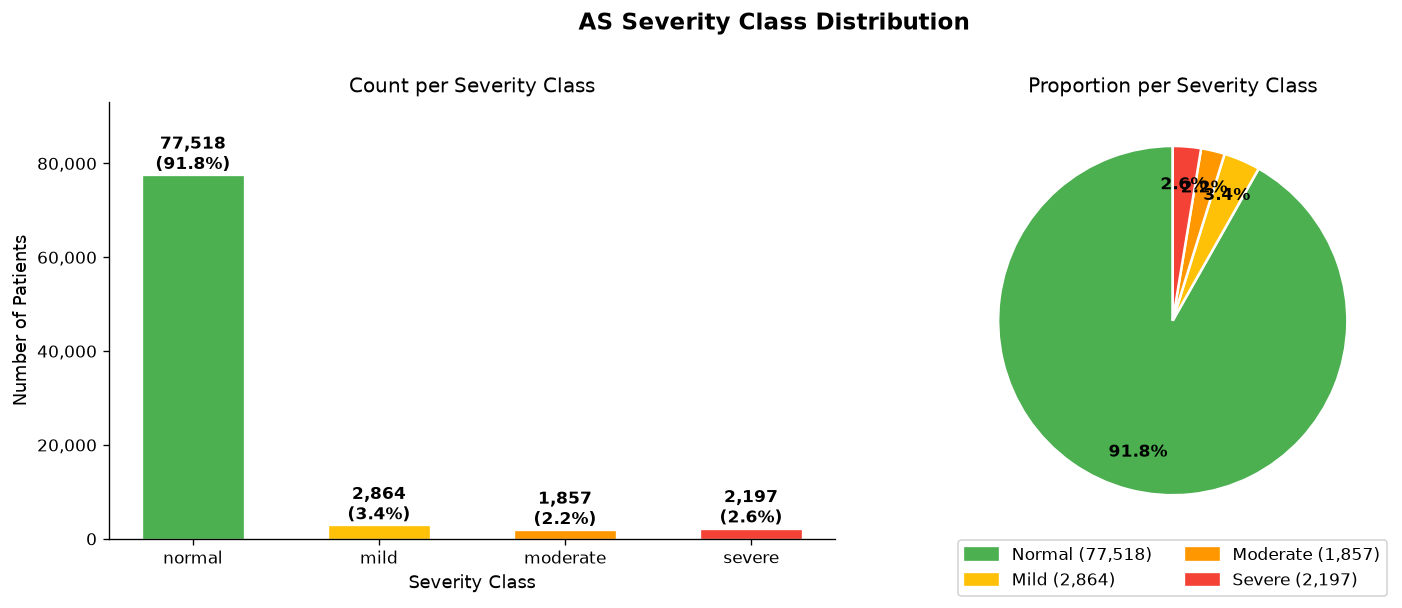

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('AS Severity Class Distribution', fontsize=14, fontweight='bold', y=1.01)

# --- Bar chart ---
ax = axes[0]
bars = ax.bar(
    CLASS_ORDER,
    [counts[c] for c in CLASS_ORDER],
    color=[CLASS_COLORS[c] for c in CLASS_ORDER],
    edgecolor='white', linewidth=0.8, width=0.55
)
for bar, cls in zip(bars, CLASS_ORDER):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 100,
            f'{h:,}\n({pct[cls]:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xlabel('Severity Class', fontsize=11)
ax.set_ylabel('Number of Patients', fontsize=11)
ax.set_title('Count per Severity Class', fontsize=12)
ax.set_ylim(0, counts.max() * 1.2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# --- Pie chart ---
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    [counts[c] for c in CLASS_ORDER],
    labels=None,
    autopct='%1.1f%%',
    colors=[CLASS_COLORS[c] for c in CLASS_ORDER],
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(linewidth=1.5, edgecolor='white'),
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
patches = [mpatches.Patch(color=CLASS_COLORS[c], label=f'{c.capitalize()} ({counts[c]:,})') for c in CLASS_ORDER]
ax.legend(handles=patches, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=10)
ax.set_title('Proportion per Severity Class', fontsize=12)

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

### 1.4 Split-Aware Data Partitioning

The dataset ships with a pre-defined `split` column (`train`, `val`, `test`, `no_split`). We honour these splits to prevent data leakage — **undersampling is applied only to the training set**, and `no_split` rows are excluded from modelling since their assignment is unknown.

In [7]:
# Separate by pre-defined split labels
SPLIT_LABELS = ['train', 'val', 'test', 'no_split']
df_splits = {label: df[df['split'] == label].copy() for label in SPLIT_LABELS}

print('Raw split sizes (after AS class filtering):')
for name, subset in df_splits.items():
    print(f'  {name:10s}: {len(subset):6,} rows')

Raw split sizes (after AS class filtering):
  train     : 61,147 rows
  val       :  3,739 rows
  test      :  4,436 rows
  no_split  : 15,114 rows


In [8]:
# Overview table: counts + % per split × severity class
rows = {}
for split_name in SPLIT_LABELS:
    subset = df_splits[split_name]
    counts = subset['severity'].value_counts().reindex(CLASS_ORDER).fillna(0).astype(int)
    pct    = (counts / counts.sum() * 100).round(1)
    rows[split_name] = {cls: f"{counts[cls]:,}  ({pct[cls]:.1f}%)" for cls in CLASS_ORDER}
    rows[split_name]['Total'] = f"{counts.sum():,}"

raw_overview = pd.DataFrame(rows).T
raw_overview.index = ['Train', 'Val', 'Test', 'No-Split']
raw_overview.index.name = 'Split'
raw_overview.columns = [c.capitalize() for c in CLASS_ORDER] + ['Total']

display(raw_overview.style
    .set_caption('Raw class distribution per data split (before rebalancing)')
    .set_properties(**{'text-align': 'center', 'min-width': '140px'})
    .map(lambda _: 'font-weight: bold', subset=['Total'])
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '11px'), ('text-align', 'center')]},
        {'selector': 'caption', 'props': [('font-size', '13px'), ('font-weight', 'bold'), ('margin-bottom', '8px')]},
    ])
)

,Normal,Mild,Moderate,Severe,Total
Split,,,,,
Train,"56,254 (92.0%)","1,974 (3.2%)","1,339 (2.2%)","1,580 (2.6%)","61,147"
Val,"3,351 (89.6%)",136 (3.6%),101 (2.7%),151 (4.0%),"3,739"
Test,"3,999 (90.1%)",151 (3.4%),114 (2.6%),172 (3.9%),"4,436"
No-Split,"13,914 (92.1%)",603 (4.0%),303 (2.0%),294 (1.9%),"15,114"


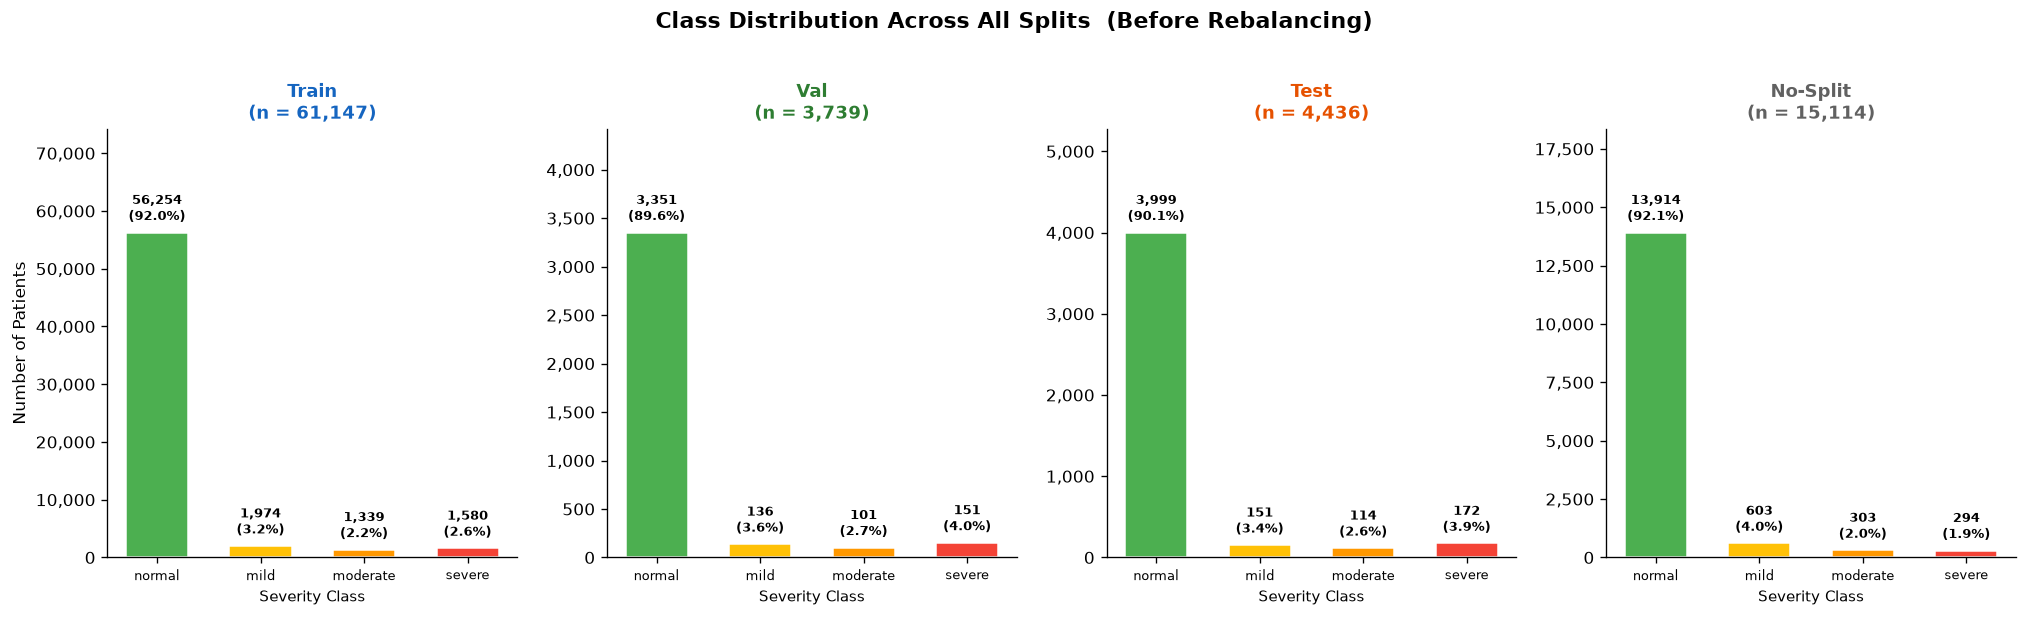

In [9]:
# 4-panel chart: one panel per split, bars coloured by severity class
SPLIT_META = {
    'train':    ('Train',    '#1565C0'),
    'val':      ('Val',      '#2E7D32'),
    'test':     ('Test',     '#E65100'),
    'no_split': ('No-Split', '#616161'),
}

fig, axes = plt.subplots(1, 4, figsize=(17, 5))
fig.suptitle('Class Distribution Across All Splits  (Before Rebalancing)',
             fontsize=13, fontweight='bold', y=1.02)

for ax, split_name in zip(axes, SPLIT_LABELS):
    subset  = df_splits[split_name]
    counts  = subset['severity'].value_counts().reindex(CLASS_ORDER).fillna(0)
    pct     = counts / counts.sum() * 100
    label, title_color = SPLIT_META[split_name]

    bars = ax.bar(
        CLASS_ORDER,
        counts,
        color=[CLASS_COLORS[c] for c in CLASS_ORDER],
        edgecolor='white', linewidth=0.9, width=0.6,
    )
    for bar, cls in zip(bars, CLASS_ORDER):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + counts.max() * 0.025,
                f'{int(h):,}\n({pct[cls]:.1f}%)',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_title(f'{label}\n(n = {len(subset):,})', fontsize=10.5,
                 color=title_color, fontweight='bold')
    ax.set_ylim(0, counts.max() * 1.32)
    ax.set_xlabel('Severity Class', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(axis='x', labelsize=8)

axes[0].set_ylabel('Number of Patients', fontsize=10)
plt.tight_layout()
plt.savefig('split_raw_distribution.png', bbox_inches='tight')
plt.show()

#### Undersampling Normal Class in Train Only

`no_split` rows are **excluded** — their split origin is unknown, and including them risks silent leakage.  
Random undersampling caps `normal` at **3,000** within the training split only. Val and test are left untouched so their metrics reflect real-world prevalence.

In [10]:
NORMAL_CAP = 3_000

train_normal   = df_splits['train'][df_splits['train']['severity'] == 'normal'].sample(n=NORMAL_CAP, random_state=42)
train_minority = df_splits['train'][df_splits['train']['severity'] != 'normal']

df_train = pd.concat([train_normal, train_minority], ignore_index=True)
df_train['severity'] = pd.Categorical(df_train['severity'], categories=CLASS_ORDER, ordered=True)

df_val  = df_splits['val'].copy()
df_test = df_splits['test'].copy()

print(f'df_train : {len(df_train):,} rows')
print(f'df_val   : {len(df_val):,} rows')
print(f'df_test  : {len(df_test):,} rows')

df_train : 7,893 rows
df_val   : 3,739 rows
df_test  : 4,436 rows


In [11]:
# Consolidated summary table: train (before/after), val, test
counts_train_before = df_splits['train']['severity'].value_counts().reindex(CLASS_ORDER)
counts_train_after  = df_train['severity'].value_counts().reindex(CLASS_ORDER)
counts_val          = df_val['severity'].value_counts().reindex(CLASS_ORDER)
counts_test         = df_test['severity'].value_counts().reindex(CLASS_ORDER)

def fmt(counts):
    pct = counts / counts.sum() * 100
    return [f"{counts[c]:,}  ({pct[c]:.1f}%)" for c in CLASS_ORDER]

summary_table = pd.DataFrame({
    'Train — before': fmt(counts_train_before),
    'Train — after ▼': fmt(counts_train_after),
    'Validation':       fmt(counts_val),
    'Test':             fmt(counts_test),
}, index=[c.capitalize() for c in CLASS_ORDER])
summary_table.index.name = 'Severity'

totals = {
    'Train — before':  f"{counts_train_before.sum():,}",
    'Train — after ▼': f"{counts_train_after.sum():,}",
    'Validation':       f"{counts_val.sum():,}",
    'Test':             f"{counts_test.sum():,}",
}
summary_table.loc['Total'] = totals

display(summary_table.style
    .set_caption('Final class distribution: Train (before / after undersampling), Validation, Test')
    .set_properties(**{'text-align': 'center', 'min-width': '180px'})
    .map(lambda _: 'font-weight: bold; background-color: #f5f5f5', subset=pd.IndexSlice[['Total'], :])
    .set_table_styles([
        {'selector': 'th.col_heading',   'props': [('font-size','11px'), ('text-align','center'), ('padding','6px')]},
        {'selector': 'caption', 'props': [('font-size','13px'), ('font-weight','bold'), ('margin-bottom','8px')]},
    ])
)

,Train — before,Train — after ▼,Validation,Test
Severity,,,,
Normal,"56,254 (92.0%)","3,000 (38.0%)","3,351 (89.6%)","3,999 (90.1%)"
Mild,"1,974 (3.2%)","1,974 (25.0%)",136 (3.6%),151 (3.4%)
Moderate,"1,339 (2.2%)","1,339 (17.0%)",101 (2.7%),114 (2.6%)
Severe,"1,580 (2.6%)","1,580 (20.0%)",151 (4.0%),172 (3.9%)
Total,"61,147","7,893","3,739","4,436"


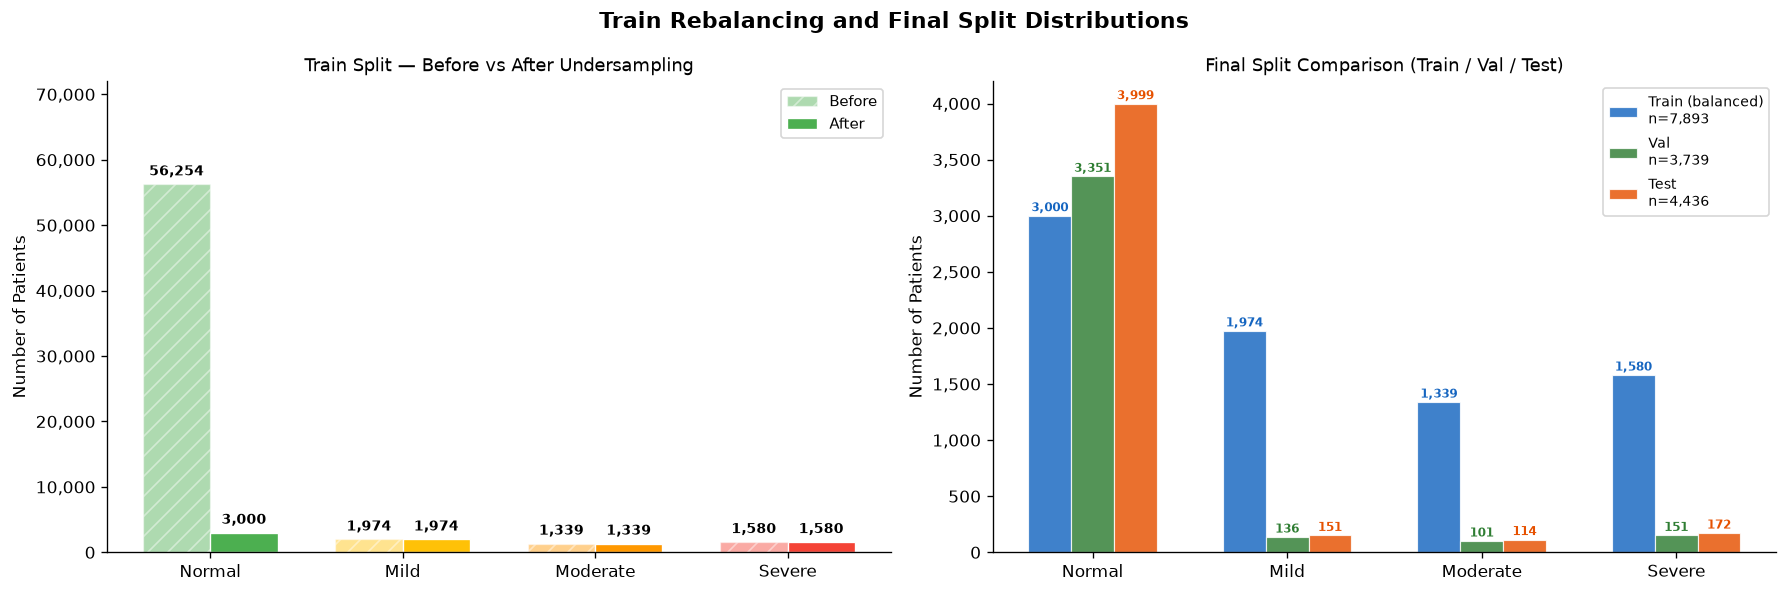

In [12]:
# Left: train before vs after   |   Right: final three-split comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Train Rebalancing and Final Split Distributions', fontsize=13, fontweight='bold')

# --- Left: train before vs after (grouped bars) ---
ax = axes[0]
x     = np.arange(len(CLASS_ORDER))
width = 0.35

bars_before = ax.bar(x - width/2, [counts_train_before[c] for c in CLASS_ORDER],
                     width, label='Before', color=[CLASS_COLORS[c] for c in CLASS_ORDER],
                     alpha=0.45, edgecolor='white', linewidth=0.8, hatch='//')
bars_after  = ax.bar(x + width/2, [counts_train_after[c] for c in CLASS_ORDER],
                     width, label='After', color=[CLASS_COLORS[c] for c in CLASS_ORDER],
                     edgecolor='white', linewidth=0.8)

for bars, counts in [(bars_before, counts_train_before), (bars_after, counts_train_after)]:
    for bar, cls in zip(bars, CLASS_ORDER):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + counts_train_before.max() * 0.015,
                f'{int(h):,}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_title('Train Split — Before vs After Undersampling', fontsize=11)
ax.set_ylabel('Number of Patients', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in CLASS_ORDER])
ax.set_ylim(0, counts_train_before.max() * 1.28)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend(fontsize=9)

# --- Right: final balanced train / val / test side-by-side ---
ax = axes[1]
final_splits = [
    (counts_train_after, f'Train (balanced)\nn={len(df_train):,}', '#1565C0'),
    (counts_val,         f'Val\nn={len(df_val):,}',               '#2E7D32'),
    (counts_test,        f'Test\nn={len(df_test):,}',             '#E65100'),
]

x     = np.arange(len(CLASS_ORDER))
width = 0.22
offsets = [-width, 0, width]

for (counts, label, color), offset in zip(final_splits, offsets):
    bars = ax.bar(x + offset, [counts[c] for c in CLASS_ORDER],
                  width, label=label, color=color, alpha=0.82,
                  edgecolor='white', linewidth=0.7)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    h + 15, f'{int(h):,}',
                    ha='center', va='bottom', fontsize=7, fontweight='bold', color=color)

ax.set_title('Final Split Comparison (Train / Val / Test)', fontsize=11)
ax.set_ylabel('Number of Patients', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in CLASS_ORDER])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend(fontsize=8.5, loc='upper right')

plt.tight_layout()
plt.savefig('split_final_distribution.png', bbox_inches='tight')
plt.show()

### 1.5 Missing Value Analysis for Selected Features

In [13]:
missing = df[ALL_FEATURES].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

miss_df = pd.DataFrame({
    'Feature Group': (
        ['ECG'] * len(ECG_FEATURES) + ['Echo'] * len(ECHO_FEATURES) + ['Demo'] * len(DEMO_FEATURES)
    ),
    'Missing Count': missing.values,
    'Missing (%)': missing_pct.values,
}, index=ALL_FEATURES)
miss_df.index.name = 'Feature'

display(miss_df.style
    .background_gradient(cmap='Reds', subset=['Missing (%)'])
    .format({'Missing Count': '{:,}', 'Missing (%)': '{:.2f}%'})
)

,Feature Group,Missing Count,Missing (%)
Feature,,,
pr_interval,ECG,"9,199",10.89%
qrs_duration,ECG,0,0.00%
qt_corrected,ECG,1,0.00%
ventricular_rate,ECG,0,0.00%
atrial_rate,ECG,561,0.66%
ivs_measurement,Echo,162,0.19%
lvpw_measurement,Echo,156,0.18%
pasp_value,Echo,"30,810",36.49%
tr_max_velocity_value,Echo,"41,521",49.17%


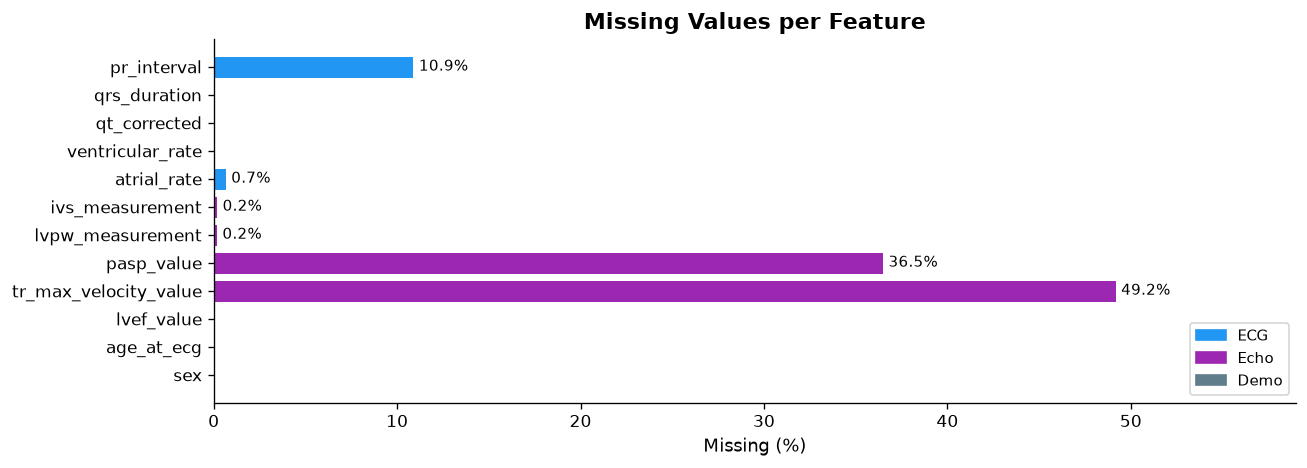

In [14]:
fig, ax = plt.subplots(figsize=(11, 4))

group_colors = {'ECG': '#2196F3', 'Echo': '#9C27B0', 'Demo': '#607D8B'}
bar_colors = (
    [group_colors['ECG']] * len(ECG_FEATURES) +
    [group_colors['Echo']] * len(ECHO_FEATURES) +
    [group_colors['Demo']] * len(DEMO_FEATURES)
)

bars = ax.barh(ALL_FEATURES[::-1], missing_pct.values[::-1], color=bar_colors[::-1],
               edgecolor='white', linewidth=0.6)
for bar, val in zip(bars, missing_pct.values[::-1]):
    if val > 0:
        ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=9)

patches = [mpatches.Patch(color=v, label=k) for k, v in group_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('Missing (%)', fontsize=11)
ax.set_title('Missing Values per Feature', fontsize=13, fontweight='bold')
ax.set_xlim(0, max(missing_pct.max() * 1.2, 5))
plt.tight_layout()
plt.savefig('missing_values.png', bbox_inches='tight')
plt.show()

### 1.6 ECG Feature Distributions by Severity

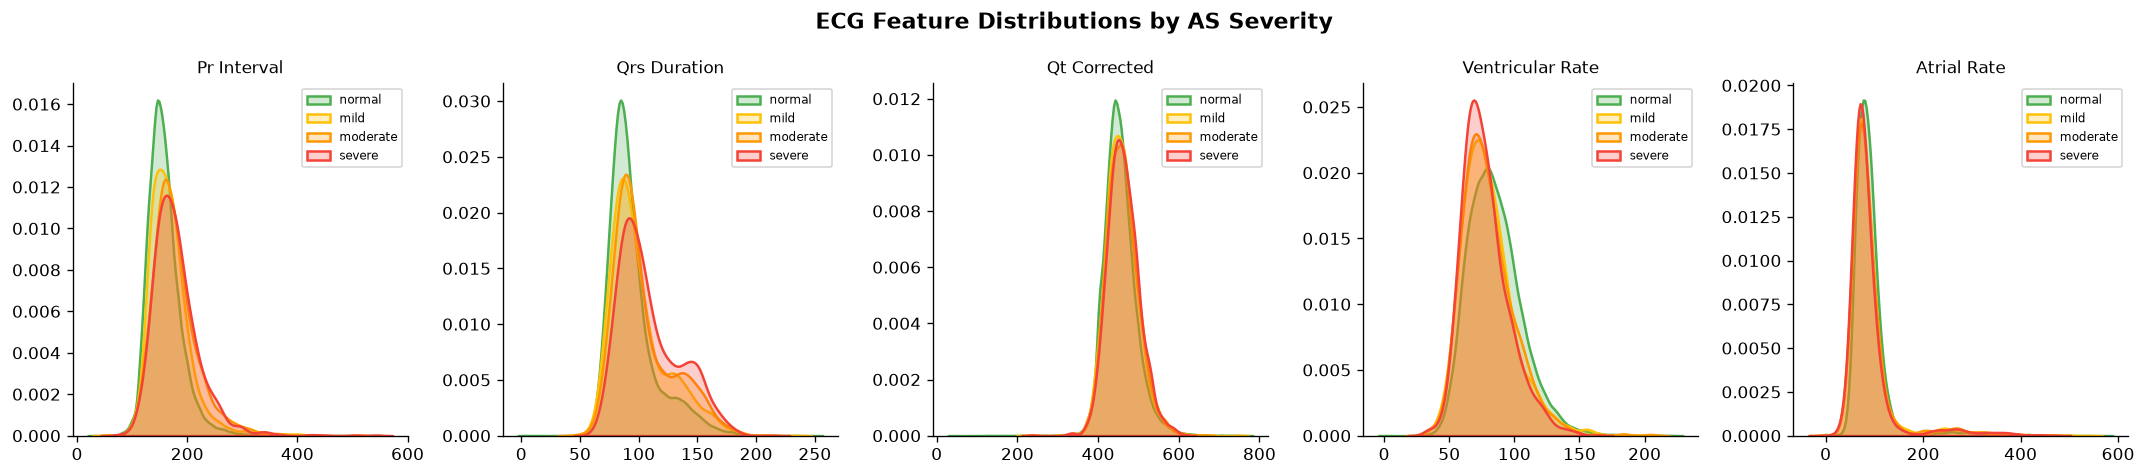

In [15]:
fig, axes = plt.subplots(1, len(ECG_FEATURES), figsize=(18, 4))
fig.suptitle('ECG Feature Distributions by AS Severity', fontsize=13, fontweight='bold')

for ax, feat in zip(axes, ECG_FEATURES):
    for cls in CLASS_ORDER:
        vals = df.loc[df['severity'] == cls, feat].dropna()
        if len(vals) > 0:
            sns.kdeplot(vals, ax=ax, label=cls, color=CLASS_COLORS[cls],
                        fill=True, alpha=0.25, linewidth=1.5)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('ecg_distributions.png', bbox_inches='tight')
plt.show()

### 1.7 Echo Feature Distributions by Severity

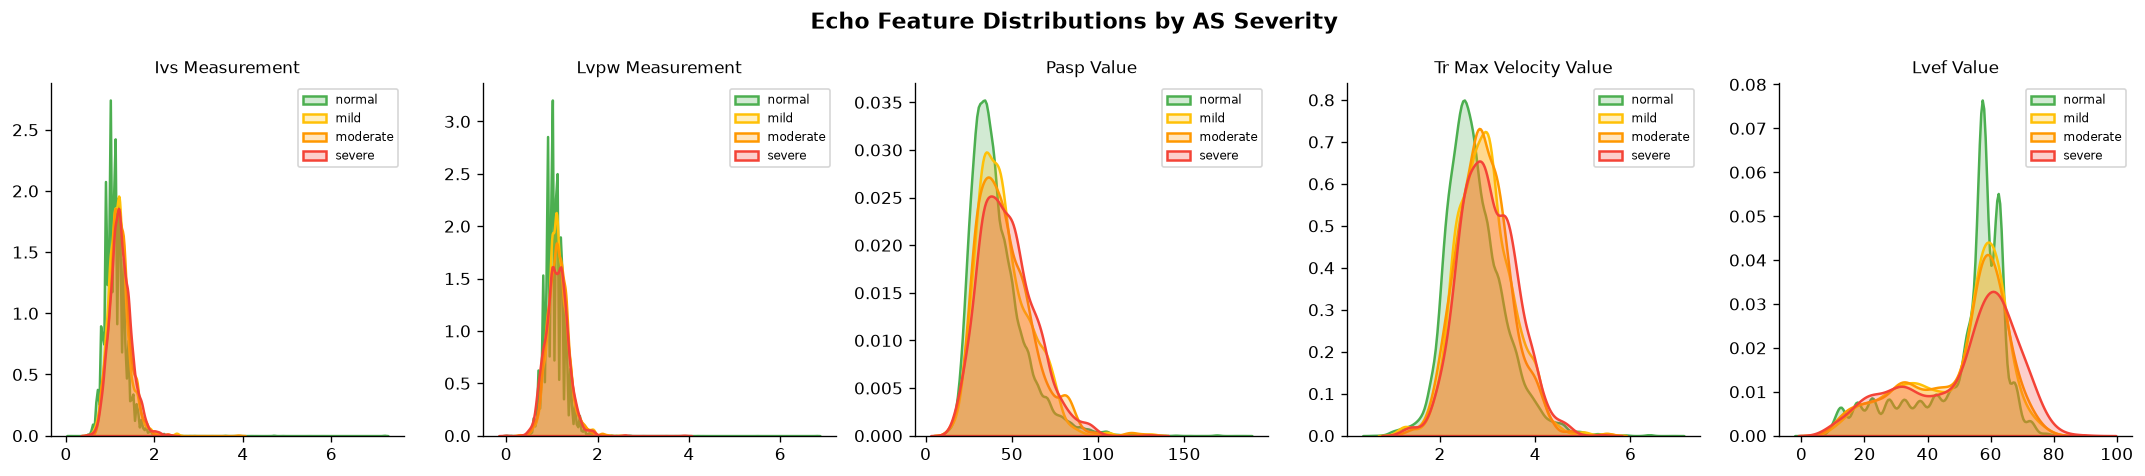

In [16]:
fig, axes = plt.subplots(1, len(ECHO_FEATURES), figsize=(18, 4))
fig.suptitle('Echo Feature Distributions by AS Severity', fontsize=13, fontweight='bold')

for ax, feat in zip(axes, ECHO_FEATURES):
    for cls in CLASS_ORDER:
        vals = df.loc[df['severity'] == cls, feat].dropna()
        if len(vals) > 0:
            sns.kdeplot(vals, ax=ax, label=cls, color=CLASS_COLORS[cls],
                        fill=True, alpha=0.25, linewidth=1.5)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('echo_distributions.png', bbox_inches='tight')
plt.show()

### 1.8 Demographic Features by Severity

/tmp/claude-501/ipykernel_55008/4074951999.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([c.capitalize() for c in CLASS_ORDER])


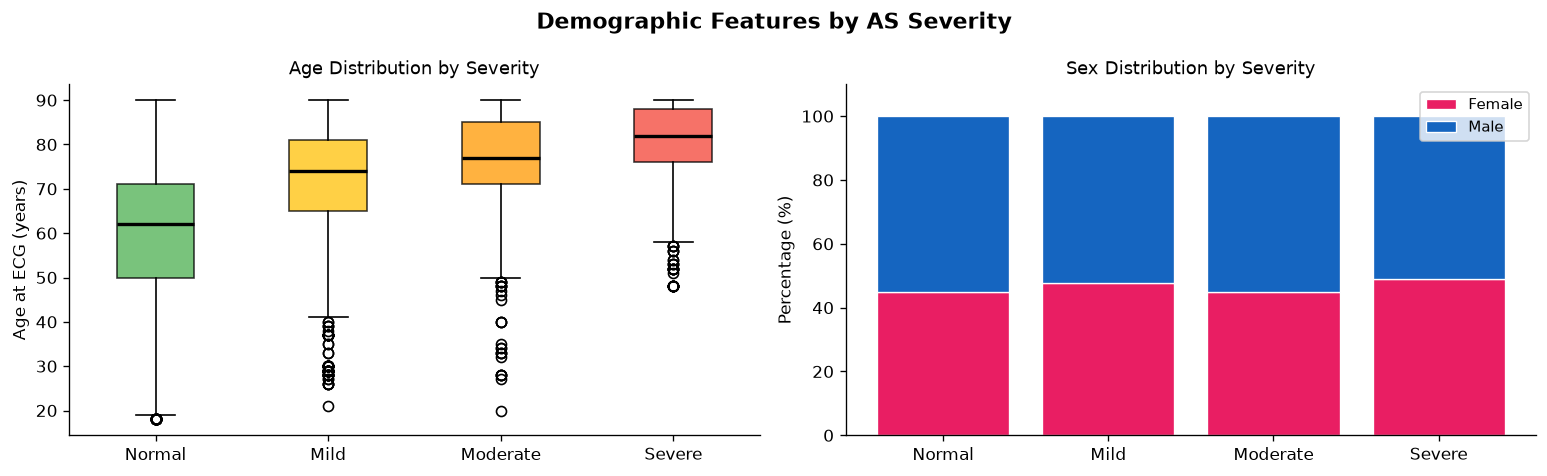

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Demographic Features by AS Severity', fontsize=13, fontweight='bold')

# Age distribution (box plot)
ax = axes[0]
data_by_class = [df.loc[df['severity'] == cls, 'age_at_ecg'].dropna().values for cls in CLASS_ORDER]
bp = ax.boxplot(data_by_class, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))
for patch, cls in zip(bp['boxes'], CLASS_ORDER):
    patch.set_facecolor(CLASS_COLORS[cls])
    patch.set_alpha(0.75)
ax.set_xticklabels([c.capitalize() for c in CLASS_ORDER])
ax.set_ylabel('Age at ECG (years)', fontsize=10)
ax.set_title('Age Distribution by Severity', fontsize=11)

# Sex distribution (stacked bar)
ax = axes[1]
sex_counts = df.groupby(['severity', 'sex'], observed=True).size().unstack(fill_value=0)
sex_pct = sex_counts.div(sex_counts.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(CLASS_ORDER))
sex_palette = {'male': '#1565C0', 'female': '#E91E63'}
for sex_val in sex_pct.columns:
    vals = [sex_pct.loc[cls, sex_val] if cls in sex_pct.index else 0 for cls in CLASS_ORDER]
    ax.bar(CLASS_ORDER, vals, bottom=bottom, color=sex_palette.get(sex_val, '#9E9E9E'),
           label=sex_val.capitalize(), edgecolor='white', linewidth=0.8)
    bottom += np.array(vals)

ax.set_ylabel('Percentage (%)', fontsize=10)
ax.set_title('Sex Distribution by Severity', fontsize=11)
ax.set_xticklabels([c.capitalize() for c in CLASS_ORDER])
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig('demo_distributions.png', bbox_inches='tight')
plt.show()

### 1.9 Summary Statistics per Severity Class

In [18]:
NUM_FEATURES = ECG_FEATURES + ECHO_FEATURES + ['age_at_ecg']

for group_name, feats in [('ECG', ECG_FEATURES), ('Echo', ECHO_FEATURES), ('Demography', ['age_at_ecg'])]:
    print(f'\n=== {group_name} Features — Mean (Std) per Severity Class ===')
    rows = {}
    for feat in feats:
        row = {}
        for cls in CLASS_ORDER:
            vals = df.loc[df['severity'] == cls, feat].dropna()
            row[cls.capitalize()] = f'{vals.mean():.1f} ± {vals.std():.1f}' if len(vals) > 0 else 'N/A'
        rows[feat] = row
    display(pd.DataFrame(rows).T.rename_axis('Feature'))


=== ECG Features — Mean (Std) per Severity Class ===


,Normal,Mild,Moderate,Severe
Feature,,,,
pr_interval,158.3 ± 31.8,167.9 ± 38.0,177.7 ± 42.0,179.1 ± 42.5
qrs_duration,94.4 ± 21.4,100.2 ± 24.7,103.1 ± 25.4,108.7 ± 25.9
qt_corrected,453.8 ± 40.1,458.4 ± 39.4,459.5 ± 39.5,461.8 ± 39.2
ventricular_rate,84.9 ± 20.6,79.6 ± 20.3,79.6 ± 20.2,77.5 ± 18.1
atrial_rate,91.1 ± 43.6,90.6 ± 54.3,90.9 ± 53.0,88.7 ± 52.9



=== Echo Features — Mean (Std) per Severity Class ===


,Normal,Mild,Moderate,Severe
Feature,,,,
ivs_measurement,1.1 ± 0.3,1.2 ± 0.2,1.2 ± 0.2,1.2 ± 0.2
lvpw_measurement,1.1 ± 0.2,1.1 ± 0.2,1.1 ± 0.2,1.1 ± 0.3
pasp_value,41.2 ± 15.5,45.1 ± 15.0,45.8 ± 16.2,47.4 ± 15.8
tr_max_velocity_value,2.7 ± 0.6,2.9 ± 0.6,2.9 ± 0.6,3.0 ± 0.6
lvef_value,51.1 ± 14.7,50.2 ± 15.3,49.9 ± 15.7,51.3 ± 17.1



=== Demography Features — Mean (Std) per Severity Class ===


,Normal,Mild,Moderate,Severe
Feature,,,,
age_at_ecg,59.9 ± 15.7,72.0 ± 12.9,76.8 ± 10.3,80.7 ± 8.4


### 1.10 EDA Summary

Key observations carried forward into modelling:

**Class distribution (final)**
| Split | Normal | Mild | Moderate | Severe | Total |
|---|---|---|---|---|---|
| Train (balanced) | 3,000 | 1,974 | 1,339 | 1,580 | 7,893 |
| Val (untouched) | 3,351 | 136 | 101 | 151 | 3,739 |
| Test (untouched) | 3,999 | 151 | 114 | 172 | 4,436 |
| No-split (excluded) | 13,914 | 603 | 303 | 294 | 15,114 |

**Modelling decisions from EDA**
- `no_split` rows are excluded — split label unknown, leakage risk.
- Val and test are intentionally imbalanced — they reflect real-world AS prevalence so metrics are clinically meaningful.
- `class_weight` will be computed from the **post-undersampling training set** and passed only to `model.fit()`.
- `tr_max_velocity_value` (~43% missing) and `pasp_value` (~32% missing) require median imputation — fit on train, applied to val/test.
- `sex` is the only categorical feature; all others are continuous.
- Age and Echo features show clear severity gradients — strong signal for the model.

## 2. FT-Transformer Model

Feature Tokenizer Transformer (Gorishniy et al., 2021) treats every feature — numeric and categorical — as an embedding token, then applies stacked Transformer layers over those tokens so the model learns cross-feature interactions. Here we adapt it for 4-class AS severity classification using 12 input features (11 numeric + `sex`).

### 2.1 Imports

In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L
from tensorflow.data import Dataset

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
)

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU devices        : {tf.config.list_physical_devices("GPU")}')
print(f'Metal available    : {"Metal" in str(tf.config.list_physical_devices())}')

TensorFlow version : 2.21.0
GPU devices        : []
Metal available    : False


### 2.2 Preprocessing Pipeline

`SimpleImputer` → `StandardScaler` is fit **only on `df_train`** and then applied to val and test, preventing any data leakage. `sex` (categorical) is passed as raw strings; the `StringLookup` layer inside the model handles it.

In [20]:
NUM_FEATURES = ECG_FEATURES + ECHO_FEATURES + ['age_at_ecg']  # 11 numeric
CAT_FEATURES = ['sex']                                         # 1 categorical

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# Fit exclusively on training data
numeric_pipeline.fit(df_train[NUM_FEATURES])

def build_X(df):
    """Impute + scale numeric features, attach categorical as-is."""
    X_num = pd.DataFrame(
        numeric_pipeline.transform(df[NUM_FEATURES]).astype('float32'),
        columns=NUM_FEATURES,
    )
    X_cat = df[CAT_FEATURES].reset_index(drop=True)
    return pd.concat([X_num, X_cat], axis=1)

X_train = build_X(df_train)
X_val   = build_X(df_val)
X_test  = build_X(df_test)

print(f'X_train : {X_train.shape}  |  any NaN: {X_train[NUM_FEATURES].isnull().any().any()}')
print(f'X_val   : {X_val.shape}  |  any NaN: {X_val[NUM_FEATURES].isnull().any().any()}')
print(f'X_test  : {X_test.shape}  |  any NaN: {X_test[NUM_FEATURES].isnull().any().any()}')

X_train : (7893, 12)  |  any NaN: False
X_val   : (3739, 12)  |  any NaN: False
X_test  : (4436, 12)  |  any NaN: False


### 2.3 Target Encoding & Class Weights

In [21]:
# One-hot encode targets; column order locked to CLASS_ORDER so label index is deterministic
y_train = pd.get_dummies(df_train['severity'])[CLASS_ORDER].astype('float32')
y_val   = pd.get_dummies(df_val['severity'])[CLASS_ORDER].astype('float32')
y_test  = pd.get_dummies(df_test['severity'])[CLASS_ORDER].astype('float32')

# Class weights from post-undersampling train distribution only
label_to_idx = {cls: i for i, cls in enumerate(CLASS_ORDER)}
y_train_int  = df_train['severity'].map(label_to_idx).values
raw_cw       = compute_class_weight('balanced', classes=np.arange(len(CLASS_ORDER)), y=y_train_int)
class_weight = {i: float(w) for i, w in enumerate(raw_cw)}

cw_table = pd.DataFrame({
    'Class':        [c.capitalize() for c in CLASS_ORDER],
    'Train count':  [int((y_train_int == i).sum()) for i in range(len(CLASS_ORDER))],
    'Weight':       [round(raw_cw[i], 4) for i in range(len(CLASS_ORDER))],
})
cw_table.index = cw_table.pop('Class')
display(cw_table.style
    .background_gradient(cmap='RdYlGn_r', subset=['Weight'])
    .format({'Train count': '{:,}', 'Weight': '{:.4f}'})
    .set_caption('Class weights applied during training (higher = model penalised more for getting that class wrong)')
    .set_properties(**{'text-align': 'center'})
)
print(f'\nclass_weight dict → {class_weight}')

,Train count,Weight
Class,,
Normal,"3,000",0.6577
Mild,"1,974",0.9996
Moderate,"1,339",1.4737
Severe,"1,580",1.2489



class_weight dict → {0: 0.65775, 1: 0.9996200607902735, 2: 1.4736743838685586, 3: 1.2488924050632912}


### 2.4 Data Configuration & Loading

In [22]:
class DataConfig:
    """Separates features into numeric and categorical; holds the categorical vocabulary."""
    def __init__(self, numeric_feature_names, categorical_features_with_vocabulary):
        self.NUMERIC_FEATURE_NAMES = numeric_feature_names
        self.CATEGORICAL_FEATURES_WITH_VOCABULARY = categorical_features_with_vocabulary
        self.CATEGORICAL_FEATURE_NAMES = list(categorical_features_with_vocabulary.keys())
        self.FEATURE_NAMES = numeric_feature_names + self.CATEGORICAL_FEATURE_NAMES


class DataLoader:
    """Wraps a pandas DataFrame into a tf.data.Dataset of feature dicts."""
    @classmethod
    def from_df(cls, X, y=None, batch_size=256):
        feature_dict = {col: X[col].values.tolist() for col in X.columns}
        if y is not None:
            return (Dataset
                    .from_tensor_slices((feature_dict, y.values.tolist()))
                    .batch(batch_size)
                    .prefetch(tf.data.AUTOTUNE))
        return (Dataset
                .from_tensor_slices(feature_dict)
                .batch(batch_size)
                .prefetch(tf.data.AUTOTUNE))


BATCH_SIZE = 256

data_train = DataLoader.from_df(X_train, y_train, batch_size=BATCH_SIZE)
data_val   = DataLoader.from_df(X_val,   y_val,   batch_size=BATCH_SIZE)
data_test  = DataLoader.from_df(X_test,            batch_size=BATCH_SIZE)

print('DataLoader — batch shapes:')
for features, labels in data_train.take(1):
    for name, tensor in list(features.items())[:3]:
        print(f'  {name:30s}: {tensor.shape}  dtype={tensor.dtype}')
    print(f'  ...({len(features)} features total)')
    print(f'  labels                          : {labels.shape}  dtype={labels.dtype}')

DataLoader — batch shapes:
  pr_interval                   : (256,)  dtype=<dtype: 'float32'>
  qrs_duration                  : (256,)  dtype=<dtype: 'float32'>
  qt_corrected                  : (256,)  dtype=<dtype: 'float32'>
  ...(12 features total)
  labels                          : (256, 4)  dtype=<dtype: 'float32'>


### 2.5 Model Architecture

Three components make up the FT-Transformer:
1. **Input + Encoding** — numeric scalars projected to `embedding_dim` via Dense; categorical strings via StringLookup → Embedding
2. **Transformer Blocks** — stacked Multi-Head Self-Attention + FFN + LayerNorm
3. **Output head** — GlobalAveragePooling over all 12 token embeddings → Dense(4, softmax)

In [23]:
def get_inputs(config):
    """Build a dict of Keras Input layers — float32 for numeric, string for categorical."""
    return {
        name: L.Input(
            name=name, shape=(),
            dtype=tf.float32 if name in config.NUMERIC_FEATURE_NAMES else tf.string,
        )
        for name in config.FEATURE_NAMES
    }


def encode_inputs(inputs, config, embedding_dim):
    """
    Project every feature to a (1, embedding_dim) token:
      - Numeric  : Reshape(1,) → Dense(embedding_dim)
      - Categorical: StringLookup → Embedding(vocab_size, embedding_dim)
    Returns two lists: (num_tokens, cat_tokens)
    """
    num_tokens, cat_tokens = [], []

    for name in config.FEATURE_NAMES:
        if name in config.CATEGORICAL_FEATURE_NAMES:
            vocab   = config.CATEGORICAL_FEATURES_WITH_VOCABULARY[name]
            lookup  = L.StringLookup(
                vocabulary=vocab, mask_token=None, num_oov_indices=0,
                output_mode='int', name=f'{name}_lookup',
            )
            embed   = L.Embedding(
                input_dim=len(vocab), output_dim=embedding_dim,
                name=f'{name}_embedding',
            )
            token   = embed(lookup(L.Reshape((1,), name=f'{name}_reshape')(inputs[name])))
            cat_tokens.append(token)
        else:
            token   = L.Reshape((1,), name=f'{name}_reshape')(inputs[name])
            num_tokens.append(token)

    return num_tokens, cat_tokens

In [24]:
class TransformerBlock(L.Layer):
    """Single Transformer layer: Multi-Head Self-Attention → Add & Norm → FFN → Add & Norm."""
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.attention  = L.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.ffn        = keras.Sequential([
            L.Dense(dense_dim, activation='relu'),
            L.Dense(embed_dim),
        ])
        self.layernorm1 = L.LayerNormalization()
        self.layernorm2 = L.LayerNormalization()

    def call(self, inputs, training=False):
        attn_out  = self.attention(inputs, inputs, training=training)
        x         = self.layernorm1(inputs + attn_out)
        ffn_out   = self.ffn(x, training=training)
        return self.layernorm2(x + ffn_out)


class FeatureTokenizerTransformerConfig:
    def __init__(
        self,
        num_outputs,
        out_activation,
        num_transformer_blocks=2,
        num_heads=4,
        embedding_dim=32,
        dense_dim=32,
        dropout_rate=0.1,
    ):
        self.NUM_OUT               = num_outputs
        self.OUT_ACTIVATION        = out_activation
        self.NUM_TRANSFORMER_BLOCKS = num_transformer_blocks
        self.NUM_HEADS             = num_heads
        self.EMBEDDING_DIM         = embedding_dim
        self.DENSE_DIM             = dense_dim
        self.DROPOUT_RATE          = dropout_rate


class FeatureTokenizerTransformer:
    @classmethod
    def from_config(cls, data_config, model_config, name='ftt'):
        inputs             = get_inputs(data_config)
        num_tokens, cat_tokens = encode_inputs(inputs, data_config, model_config.EMBEDDING_DIM)

        # Project each numeric scalar (shape (1,)) → (1, embedding_dim)
        num_projected = [
            L.Dense(model_config.EMBEDDING_DIM, name=f'{feat}_dense_proj')(token)
            for feat, token in zip(data_config.NUMERIC_FEATURE_NAMES, num_tokens)
        ]

        # Stack all tokens → (batch, num_features, embedding_dim)
        # '_tok' suffix avoids name clash with the reshape inside encode_inputs
        # Bug fix: use model_config.EMBEDDING_DIM instead of hardcoded 32
        all_tokens = num_projected + cat_tokens
        features   = L.Concatenate(axis=1, name='token_stack')([
            L.Reshape((1, model_config.EMBEDDING_DIM), name=f'{feat_name}_tok_reshape')(tok)
            for tok, feat_name in zip(all_tokens, data_config.FEATURE_NAMES)
        ])

        # Stacked Transformer blocks
        for i in range(model_config.NUM_TRANSFORMER_BLOCKS):
            features = TransformerBlock(
                embed_dim=model_config.EMBEDDING_DIM,
                dense_dim=model_config.DENSE_DIM,
                num_heads=model_config.NUM_HEADS,
                name=f'transformer_block_{i}',
            )(features)

        # Aggregate across all token positions, then classify
        features = L.Dropout(model_config.DROPOUT_RATE, name='pre_pool_dropout')(features)
        features = L.GlobalAveragePooling1D(name='global_avg_pool')(features)
        outputs  = L.Dense(
            model_config.NUM_OUT,
            activation=model_config.OUT_ACTIVATION,
            name='severity_output',
        )(features)

        return keras.Model(inputs=inputs, outputs=outputs, name=name)

### 2.6 Instantiate Model

In [25]:
data_config = DataConfig(
    numeric_feature_names=NUM_FEATURES,
    categorical_features_with_vocabulary={'sex': ['female', 'male']},
)

model_config = FeatureTokenizerTransformerConfig(
    num_outputs=len(CLASS_ORDER),   # 4
    out_activation='softmax',
    num_transformer_blocks=2,
    num_heads=4,
    embedding_dim=32,
    dense_dim=32,
    dropout_rate=0.1,
)

model = FeatureTokenizerTransformer.from_config(data_config, model_config, name='ftt_as_severity')
model.summary()

Model: "ftt_as_severity"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sex (InputLayer)    │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pr_interval         │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ qrs_duration        │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ qt_corrected        │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ventricular_rate    │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ atrial_rate         │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ivs_measurement     │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lvpw_measurement    │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pasp_value          │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tr_max_velocity_va… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lvef_value          │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_at_ecg          │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sex_reshape         │ (None, 1)         │          0 │ sex[0][0]         │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pr_interval_reshape │ (None, 1)         │          0 │ pr_interval[0][0] │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ qrs_duration_resha… │ (None, 1)         │          0 │ qrs_duration[0][… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ qt_corrected_resha… │ (None, 1)         │          0 │ qt_corrected[0][… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ventricular_rate_r… │ (None, 1)         │          0 │ ventricular_rate… │
│ (Reshape)           │                   │            │                 

 Total params: 13,828 (54.02 KB)

 Trainable params: 13,828 (54.02 KB)

 Non-trainable params: 0 (0.00 B)

### 2.7 Training

In [26]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', patience=5,
        factor=0.5, min_lr=1e-6, verbose=1,
    ),
]

history = model.fit(
    data_train,
    validation_data=data_val,
    epochs=100,
    class_weight=class_weight,   # applied to training batches only
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/100


/Users/zannujulius/Desktop/cmu/Research-CVD/Internship-June-Sept-2026/codebase/FT_transformers/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


 1/31 ━━━━━━━━━━━━━━━━━━━━ 1:56 4s/step - accuracy: 0.2930 - loss: 0.9341

 8/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8530 - loss: 0.3658 

15/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7029 - loss: 1.2880

...

18/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6335 - loss: 0.7560

24/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6393 - loss: 0.8281

30/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6436 - loss: 0.8601

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6454 - loss: 0.8595 - val_accuracy: 0.5764 - val_loss: 1.0328 - learning_rate: 3.1250e-05


Restoring model weights from the end of the best epoch: 100.


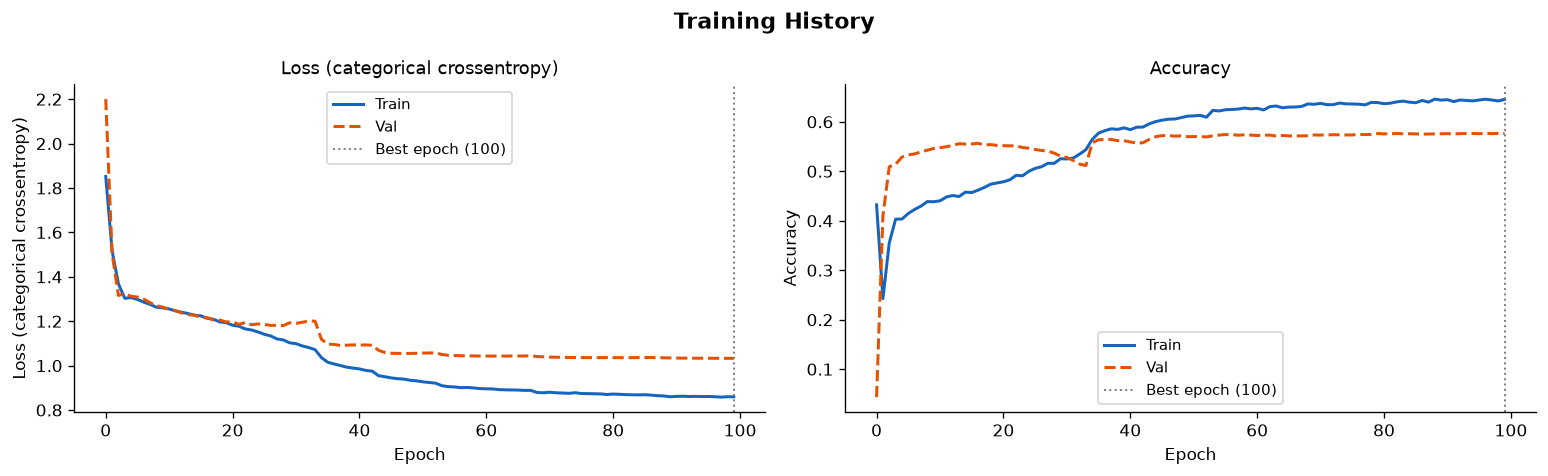

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Training History', fontsize=13, fontweight='bold')

for ax, metric, label in zip(axes, ['loss', 'accuracy'], ['Loss (categorical crossentropy)', 'Accuracy']):
    ax.plot(history.history[metric],     label='Train', color='#1565C0', linewidth=1.8)
    ax.plot(history.history[f'val_{metric}'], label='Val',   color='#E65100', linewidth=1.8, linestyle='--')
    best_ep = int(np.argmin(history.history['val_loss']))
    ax.axvline(best_ep, color='grey', linestyle=':', linewidth=1.2, label=f'Best epoch ({best_ep+1})')
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('training_history.png', bbox_inches='tight')
plt.show()

### 2.8 Evaluation

Final evaluation is performed on the **held-out test set** (4,436 rows, untouched throughout training). Val and test are both imbalanced to reflect real-world AS prevalence, so weighted and macro metrics are both reported.

In [28]:
# Predicted probabilities and hard class labels
y_prob_test  = model.predict(data_test, verbose=0)
y_pred_test  = np.argmax(y_prob_test, axis=1)
y_true_test  = np.argmax(y_test.values, axis=1)

y_prob_val   = model.predict(data_val, verbose=0)
y_pred_val   = np.argmax(y_prob_val, axis=1)
y_true_val   = np.argmax(y_val.values, axis=1)

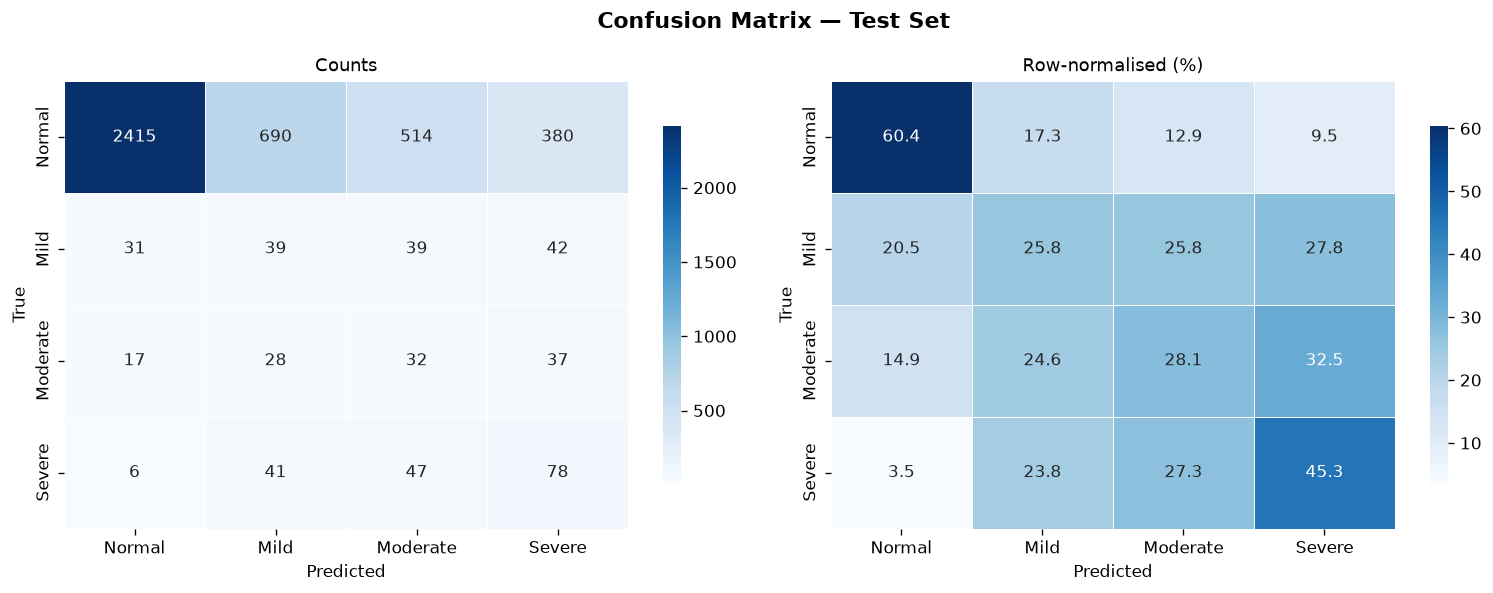

In [29]:
# Confusion matrix on test set
cm     = confusion_matrix(y_true_test, y_pred_test)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
labels = [c.capitalize() for c in CLASS_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_pct],
    ['d', '.1f'],
    ['Counts', 'Row-normalised (%)'],
):
    sns.heatmap(
        data, annot=True, fmt=fmt, ax=ax,
        cmap='Blues', linewidths=0.5,
        xticklabels=labels, yticklabels=labels,
        cbar_kws={'shrink': 0.8},
    )
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

In [30]:
# Per-class precision / recall / F1  +  AUROC  +  AUPRC
report = classification_report(
    y_true_test, y_pred_test,
    target_names=labels, output_dict=True,
)

auroc_per_class = roc_auc_score(
    y_test.values, y_prob_test, multi_class='ovr', average=None
)
auprc_per_class = [
    average_precision_score(y_test.values[:, i], y_prob_test[:, i])
    for i in range(len(CLASS_ORDER))
]

rows = {}
for i, cls in enumerate(labels):
    rows[cls] = {
        'Precision':  round(report[cls]['precision'],  4),
        'Recall':     round(report[cls]['recall'],     4),
        'F1':         round(report[cls]['f1-score'],   4),
        'Support':    int(report[cls]['support']),
        'AUROC':      round(float(auroc_per_class[i]), 4),
        'AUPRC':      round(float(auprc_per_class[i]), 4),
    }

metrics_df = pd.DataFrame(rows).T
metrics_df.index.name = 'Class'

display(metrics_df.style
    .background_gradient(cmap='RdYlGn', subset=['Precision', 'Recall', 'F1', 'AUROC', 'AUPRC'])
    .format({'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1': '{:.4f}',
             'Support': '{:,}', 'AUROC': '{:.4f}', 'AUPRC': '{:.4f}'})
    .set_caption('Per-class evaluation metrics on Test set')
    .set_properties(**{'text-align': 'center'})
)

,Precision,Recall,F1,Support,AUROC,AUPRC
Class,,,,,,
Normal,0.9781,0.6039,0.7468,"3,999.0",0.8265,0.9749
Mild,0.0489,0.2583,0.0822,151.0,0.5940,0.0462
Moderate,0.0506,0.2807,0.0858,114.0,0.7141,0.0541
Severe,0.1453,0.4535,0.2200,172.0,0.8111,0.1707


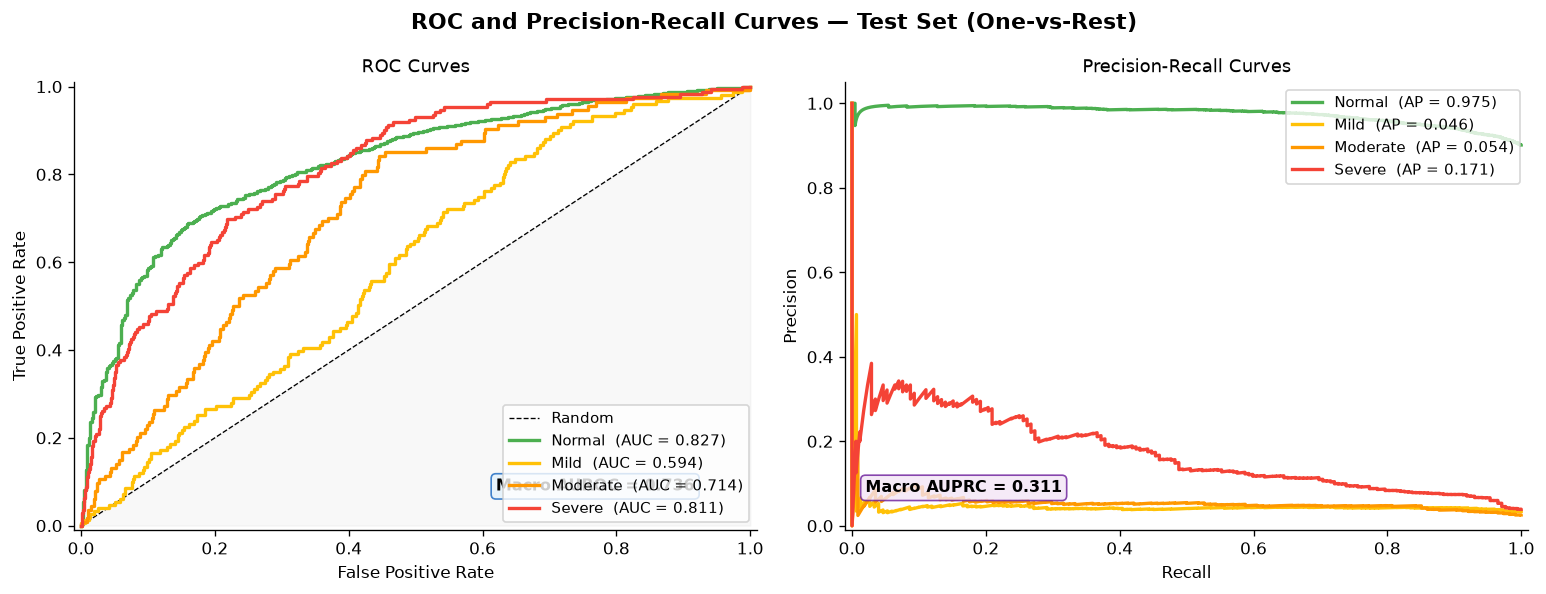

In [31]:
# ROC curves (left) + Precision-Recall curves (right) — one curve per severity class
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ROC and Precision-Recall Curves — Test Set (One-vs-Rest)', fontsize=13, fontweight='bold')

ax_roc, ax_pr = axes

# --- ROC ---
ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
for i, cls in enumerate(CLASS_ORDER):
    fpr, tpr, _ = roc_curve(y_test.values[:, i], y_prob_test[:, i])
    auc_val      = float(auroc_per_class[i])
    ax_roc.plot(fpr, tpr, color=CLASS_COLORS[cls], linewidth=2,
                label=f'{cls.capitalize()}  (AUC = {auc_val:.3f})')

ax_roc.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')
ax_roc.set_xlabel('False Positive Rate', fontsize=10)
ax_roc.set_ylabel('True Positive Rate', fontsize=10)
ax_roc.set_title('ROC Curves', fontsize=11)
ax_roc.legend(fontsize=9, loc='lower right')
ax_roc.set_xlim([-0.01, 1.01])
ax_roc.set_ylim([-0.01, 1.01])

macro_auroc = roc_auc_score(y_test.values, y_prob_test, multi_class='ovr', average='macro')
ax_roc.text(0.62, 0.08, f'Macro AUROC = {macro_auroc:.3f}',
            fontsize=9.5, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#E3F2FD', edgecolor='#1565C0', alpha=0.8))

# --- Precision-Recall ---
for i, cls in enumerate(CLASS_ORDER):
    prec, rec, _ = precision_recall_curve(y_test.values[:, i], y_prob_test[:, i])
    ap_val        = float(auprc_per_class[i])
    ax_pr.plot(rec, prec, color=CLASS_COLORS[cls], linewidth=2,
               label=f'{cls.capitalize()}  (AP = {ap_val:.3f})')

macro_auprc = float(np.mean(auprc_per_class))
ax_pr.set_xlabel('Recall', fontsize=10)
ax_pr.set_ylabel('Precision', fontsize=10)
ax_pr.set_title('Precision-Recall Curves', fontsize=11)
ax_pr.legend(fontsize=9, loc='upper right')
ax_pr.set_xlim([-0.01, 1.01])
ax_pr.set_ylim([-0.01, 1.05])
ax_pr.text(0.02, 0.08, f'Macro AUPRC = {macro_auprc:.3f}',
           fontsize=9.5, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='#F3E5F5', edgecolor='#6A1B9A', alpha=0.8))

plt.tight_layout()
plt.savefig('roc_pr_curves.png', bbox_inches='tight')
plt.show()

In [32]:
# Final summary table: aggregate metrics on both val and test
def aggregate_metrics(y_true, y_pred, y_prob, y_onehot, split_name):
    rep         = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    auroc_macro = roc_auc_score(y_onehot, y_prob, multi_class='ovr', average='macro')
    auprc_macro = float(np.mean([
        average_precision_score(y_onehot[:, i], y_prob[:, i]) for i in range(len(CLASS_ORDER))
    ]))
    return {
        'Split':             split_name,
        'Accuracy':          round(rep['accuracy'], 4),
        'Macro F1':          round(rep['macro avg']['f1-score'], 4),
        'Weighted F1':       round(rep['weighted avg']['f1-score'], 4),
        'Macro AUROC':       round(auroc_macro, 4),
        'Macro AUPRC':       round(auprc_macro, 4),
    }

summary_rows = [
    aggregate_metrics(y_true_val,  y_pred_val,  y_prob_val,  y_val.values,  'Validation'),
    aggregate_metrics(y_true_test, y_pred_test, y_prob_test, y_test.values, 'Test'),
]
summary = pd.DataFrame(summary_rows).set_index('Split')

display(summary.style
    .background_gradient(cmap='RdYlGn', subset=['Accuracy', 'Macro F1', 'Weighted F1', 'Macro AUROC', 'Macro AUPRC'])
    .format({c: '{:.4f}' for c in summary.columns})
    .set_caption('Overall evaluation metrics — Validation vs Test')
    .set_properties(**{'text-align': 'center', 'min-width': '110px'})
)

,Accuracy,Macro F1,Weighted F1,Macro AUROC,Macro AUPRC
Split,,,,,
Validation,0.5764,0.2986,0.6811,0.7362,0.3255
Test,0.5780,0.2837,0.6867,0.7364,0.3115
